<a href="https://colab.research.google.com/github/ayuannisa17/PCdVK_ganjil_2026/blob/main/Modul_3_PCdVK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
import math

from google.colab import drive
from google.colab.patches import cv2_imshow

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


/tmp/ipykernel_2551/3616201352.py:17: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)


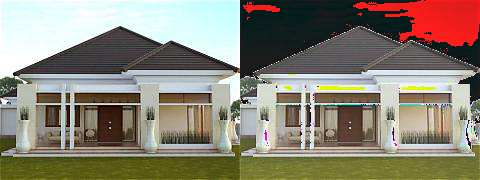

In [10]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCdVK/home.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

--- TUGAS 1: INVERSE CITRA ---


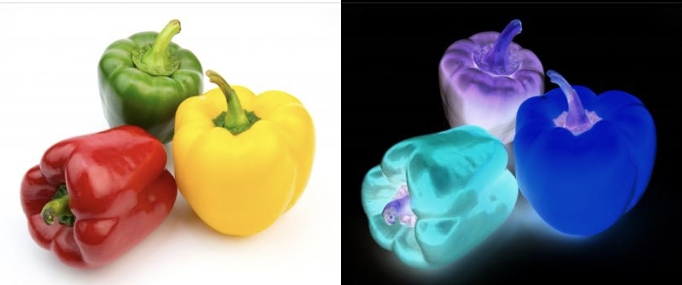

In [11]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print("--- TUGAS 1: INVERSE CITRA ---")

img_peppers = cv.imread(
    '/content/drive/MyDrive/PCdVK/buah.png'
)

if img_peppers is None:
    print("Tolong upload gambar")
else:
    inverse_image = 255 - img_peppers

    final_peppers = cv.hconcat(
        (img_peppers, inverse_image)
    )

    cv2_imshow(final_peppers)


--- TUGAS 2: KONTRAS & BRIGHTNESS ---
Mengubah kontras dan tingkat kecerahan citra
---------------------------------------------
Masukkan tingkat kecerahan : 20
Masukkan kontras : 15


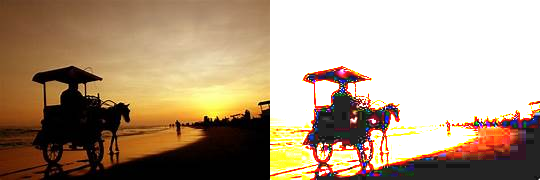

In [13]:
print("\n--- TUGAS 2: KONTRAS & BRIGHTNESS ---")
print("Mengubah kontras dan tingkat kecerahan citra")
print("---------------------------------------------")

try:
    brightness = int(input("Masukkan tingkat kecerahan : "))
    contrast = float(input("Masukkan kontras : "))
except ValueError:
    print("GAGAL!")

img_grape = cv.imread(
    '/content/drive/MyDrive/PCdVK/sunset.jpg'
)

if img_grape is None:
    print("UPLOAD GAMBAR")
else:
    contrast_image = cv.convertScaleAbs(
        img_grape,
        alpha=contrast,
        beta=brightness
    )

    final_grape = cv.hconcat(
        (img_grape, contrast_image)
    )

    cv2_imshow(final_grape)

Mengubah tingkat kecerahan citra dengan Transformasi Log
--------------------------------------------------------
Masukkan nilai kecerahan: 30


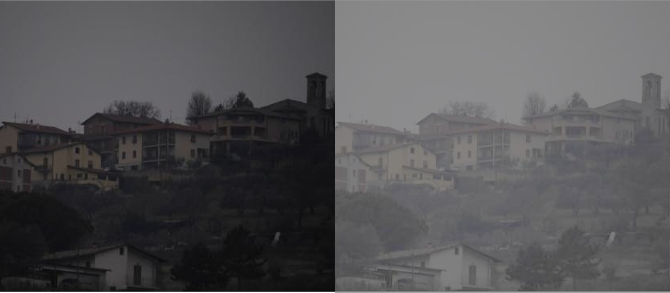

In [14]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('--------------------------------------------------------')

try:
    c = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, masukin angka yang bener Bro!')

original = cv.imread(
    '/content/drive/MyDrive/PCdVK/kota.png'
)

if original is None:
    print("Gambarnya nggak ketemu, cek path lagi!")
else:
    img_float = np.float32(original)

    log_image = c * np.log1p(img_float)

    log_image = np.clip(log_image, 0, 255)

    log_image = np.array(log_image, dtype=np.uint8)

    final_frame = cv.hconcat((original, log_image))

    cv2_imshow(final_frame)

a. Averaging


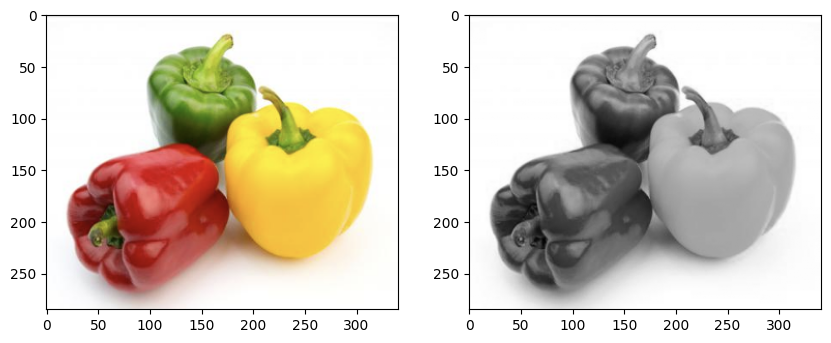

b. Lightness


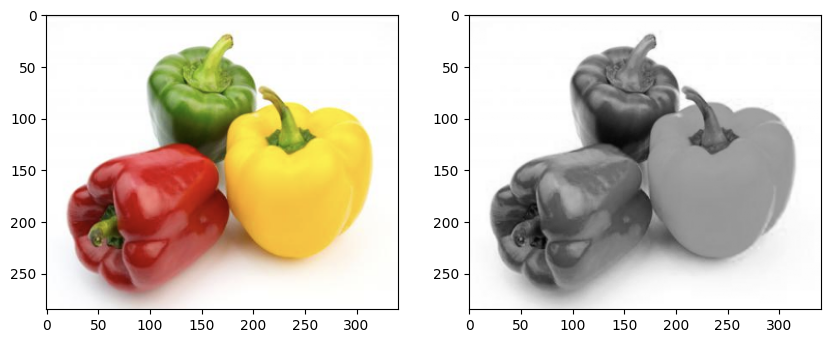

c. Luminance


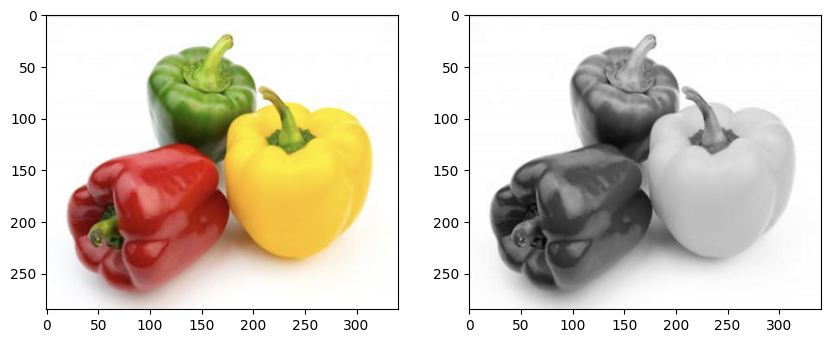

In [18]:
img_bgr = cv.imread('/content/drive/MyDrive/PCdVK/buah.png')

if img_bgr is None:
    print("Gambar Tidak Ada")
else:

    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)


    R = img_rgb[:,:,0].astype(float)
    G = img_rgb[:,:,1].astype(float)
    B = img_rgb[:,:,2].astype(float)


    avg_gray = np.uint8((R + G + B) / 3)

    max_rgb = np.maximum(np.maximum(R, G), B)
    min_rgb = np.minimum(np.minimum(R, G), B)
    lightness_gray = np.uint8((max_rgb + min_rgb) / 2)


    luminance_gray = np.uint8((0.299 * R) + (0.587 * G) + (0.114 * B))


    def tampilkan_hasil(judul, gambar_asli, gambar_gray):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))


        axes[0].imshow(gambar_asli)


        axes[1].imshow(gambar_gray, cmap='gray')


        plt.suptitle(judul, fontsize=14, x=0.1, y=1.0)
        plt.show()

    print("a. Averaging")
    tampilkan_hasil("", img_rgb, avg_gray)

    print("b. Lightness")
    tampilkan_hasil("", img_rgb, lightness_gray)

    print("c. Luminance")
    tampilkan_hasil("", img_rgb, luminance_gray)


--- TUGAS 5: COLOR FILTER ---


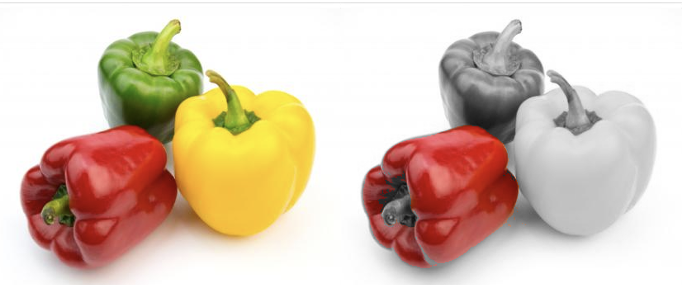

In [19]:
print("\n--- TUGAS 5: COLOR FILTER ---")

original = cv.imread(
    '/content/drive/MyDrive/PCdVK/buah.png'
)

if original is None:
    print("Gambarnya nggak ketemu, cek path lagi!")
else:
    hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

    # Deteksi warna merah
    lower_red1 = np.array([0, 100, 100])
    upper_red1 = np.array([10, 255, 255])

    lower_red2 = np.array([170, 100, 100])
    upper_red2 = np.array([180, 255, 255])

    mask1 = cv.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv.inRange(hsv, lower_red2, upper_red2)

    mask = cv.bitwise_or(mask1, mask2)

    # Ubah bagian lain menjadi grayscale
    gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
    gray = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

    result = np.where(
        mask[:, :, None] == 255,
        original,
        gray
    )

    result = np.array(result, dtype=np.uint8)

    final_frame = cv.hconcat((original, result))

    cv2_imshow(final_frame)


--- TUGAS 6: GAMMA CORRECTION ---
Gamma Correction pada citra
----------------------------
Masukkan nilai Gamma: 2


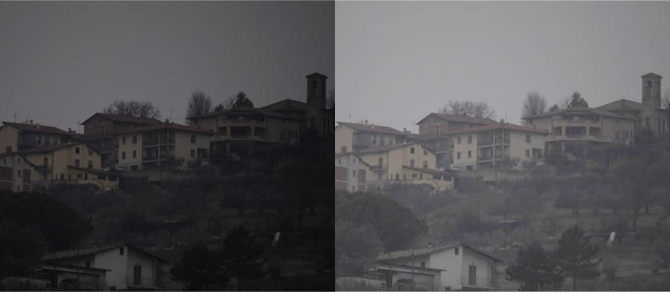

In [20]:
print("\n--- TUGAS 6: GAMMA CORRECTION ---")
print("Gamma Correction pada citra")
print("----------------------------")

try:
    gamma = float(input("Masukkan nilai Gamma: "))
except ValueError:
    print("Error, not a number")

original = cv.imread(
    '/content/drive/MyDrive/PCdVK/kota.png'
)

if original is None:
    print("Gambarnya nggak ketemu, cek path lagi!")
else:
    img_float = np.float32(original)

    gamma_image = 255 * (
        img_float / 255
    ) ** (1 / gamma)

    gamma_image = np.clip(
        gamma_image, 0, 255
    ).astype(np.uint8)

    final_frame = cv.hconcat(
        (original, gamma_image)
    )

    cv2_imshow(final_frame)

Masukkan bit depth tujuan (1-8): 3
Bit depth awal   : 8 bit
Bit depth tujuan : 3 bit
Jumlah level     : 8


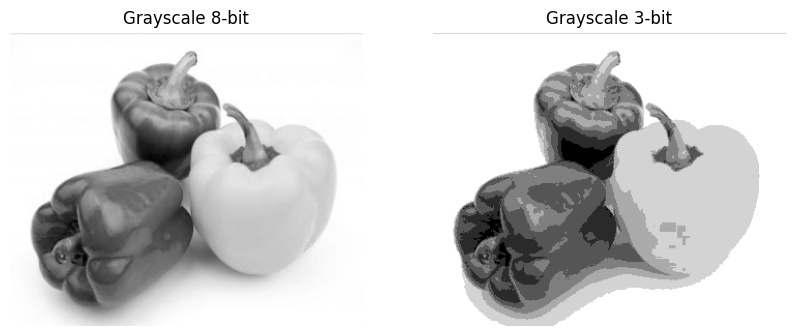

In [22]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

try:
    # Meminta input dari user
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, masukin angka dong Bro!')
    bit_depth = 8

if bit_depth < 1 or bit_depth > 8:
    print("Woi, bit depth-nya harus antara 1 sampai 8 aja ya!")
else:
    # --- MENAMPILKAN TEKS INFO ---
    num_levels = pow(2, bit_depth)
    print(f"Bit depth awal   : 8 bit")
    print(f"Bit depth tujuan : {bit_depth} bit")
    print(f"Jumlah level     : {num_levels}")


    original = cv.imread('/content/drive/MyDrive/PCdVK/buah.png', cv.IMREAD_GRAYSCALE)

    if original is None:
        print("Gambarnya nggak kebaca! Cek lagi path-nya udah bener belum.")
    else:
        # --- PROSES SIMULASI BIT DEPTH (KUANTISASI) ---
        # 1. Cari jarak antar warna (interval).
        level_step = 255 / (num_levels - 1) if bit_depth < 8 else 1

        # 2. Proses pembulatan piksel ke level terdekat

        depth_image = np.round(original / level_step) * level_step

        # 3. Ubah formatnya balik ke 8-bit integer buat ditampilin di layar
        depth_image = np.uint8(depth_image)

        # --- TAMPILKAN HASILNYA ---
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Gambar Asli (Kiri)
        axes[0].imshow(original, cmap='gray')
        axes[0].set_title('Grayscale 8-bit')
        axes[0].axis('off')

        # Gambar Hasil (Kanan)
        axes[1].imshow(depth_image, cmap='gray')
        axes[1].set_title(f'Grayscale {bit_depth}-bit')
        axes[1].axis('off')

        plt.show()

--- Eksperimen Average Denoising ---
Berhasil membaca gambar asli dan 100 gambar noise.

Jumlah Citra:  10 | Nilai PSNR: 30.60 dB
Jumlah Citra:  20 | Nilai PSNR: 32.95 dB
Jumlah Citra:  40 | Nilai PSNR: 34.89 dB
Jumlah Citra:  80 | Nilai PSNR: 36.29 dB
Jumlah Citra: 100 | Nilai PSNR: 36.63 dB


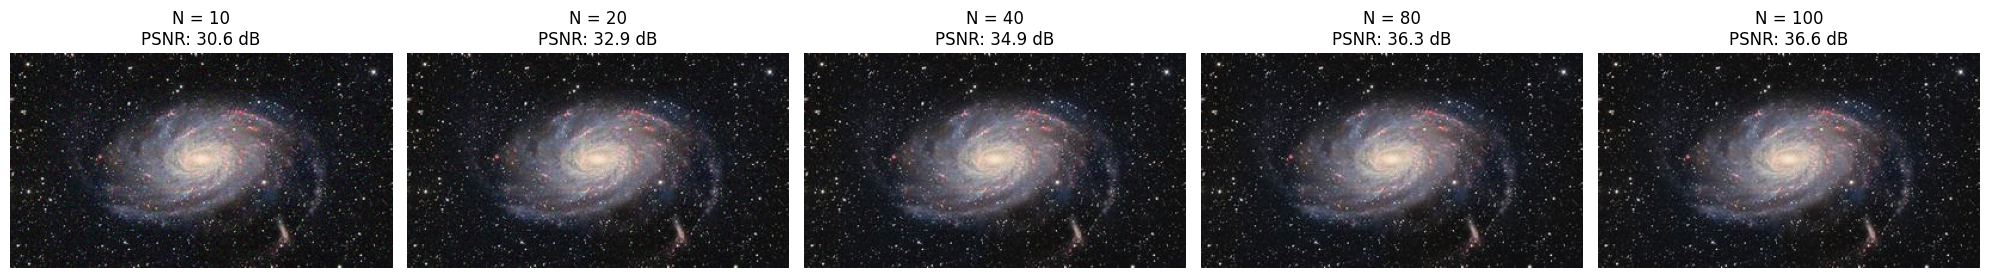

In [36]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

print('--- Eksperimen Average Denoising ---')

# Baca citra asli
path_asli = '/content/drive/MyDrive/PCdVK/galaxy.jpg'
original = cv.imread(path_asli)

if original is None:
    print("Gambar galaxy.jpg tidak ditemukan!")
else:
    # Membuat 100 citra Gaussian Noise
    cv_img = []

    for i in range(100):
        noise = np.random.normal(
            0, 25, original.shape
        )

        noisy_image = original.astype(np.float32) + noise
        noisy_image = np.clip(
            noisy_image, 0, 255
        ).astype(np.uint8)

        cv_img.append(noisy_image)

    print(f"Berhasil membaca gambar asli dan {len(cv_img)} gambar noise.\n")

    # Jumlah citra yang digunakan
    skenario_jumlah = [10, 20, 40, 80, 100]

    # Menampilkan 5 hasil sekaligus
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for idx, N in enumerate(skenario_jumlah):

        # Proses averaging
        avg_img = np.zeros(
            original.shape,
            np.float32
        )

        for img in cv_img[:N]:
            avg_img += img

        avg_img /= N
        avg_img = np.uint8(avg_img)

        # Hitung PSNR
        psnr_value = cv.PSNR(
            original,
            avg_img
        )

        # Print nilai PSNR
        print(
            f"Jumlah Citra: {N:3} | "
            f"Nilai PSNR: {psnr_value:.2f} dB"
        )

        # Tampilkan gambar
        axes[idx].imshow(
            cv.cvtColor(avg_img, cv.COLOR_BGR2RGB)
        )

        axes[idx].set_title(
            f'N = {N}\nPSNR: {psnr_value:.1f} dB'
        )

        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

1. Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
- Tidak selalu. Penambahan jumlah citra umumnya meningkatkan nilai PSNR karena noise semakin berkurang, tetapi peningkatannya semakin kecil ketika jumlah citra yang digunakan semakin banyak.

2. Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
- Peningkatan mulai tidak terlalu signifikan setelah jumlah citra mencapai sekitar 40–80 citra. Penambahan dari 80 menjadi 100 citra biasanya memberikan peningkatan PSNR yang lebih kecil dibandingkan penambahan pada jumlah citra yang lebih sedikit.

3. Apa kesimpulan yang diperoleh?
- Metode average denoising efektif untuk mengurangi Gaussian noise pada citra. Semakin banyak citra noisy yang dirata-ratakan, noise semakin berkurang dan kualitas citra meningkat. Namun, semakin banyak citra yang digunakan, peningkatan kualitas menjadi semakin kecil.

--- Eksperimen Image Masking (Bitwise) ---


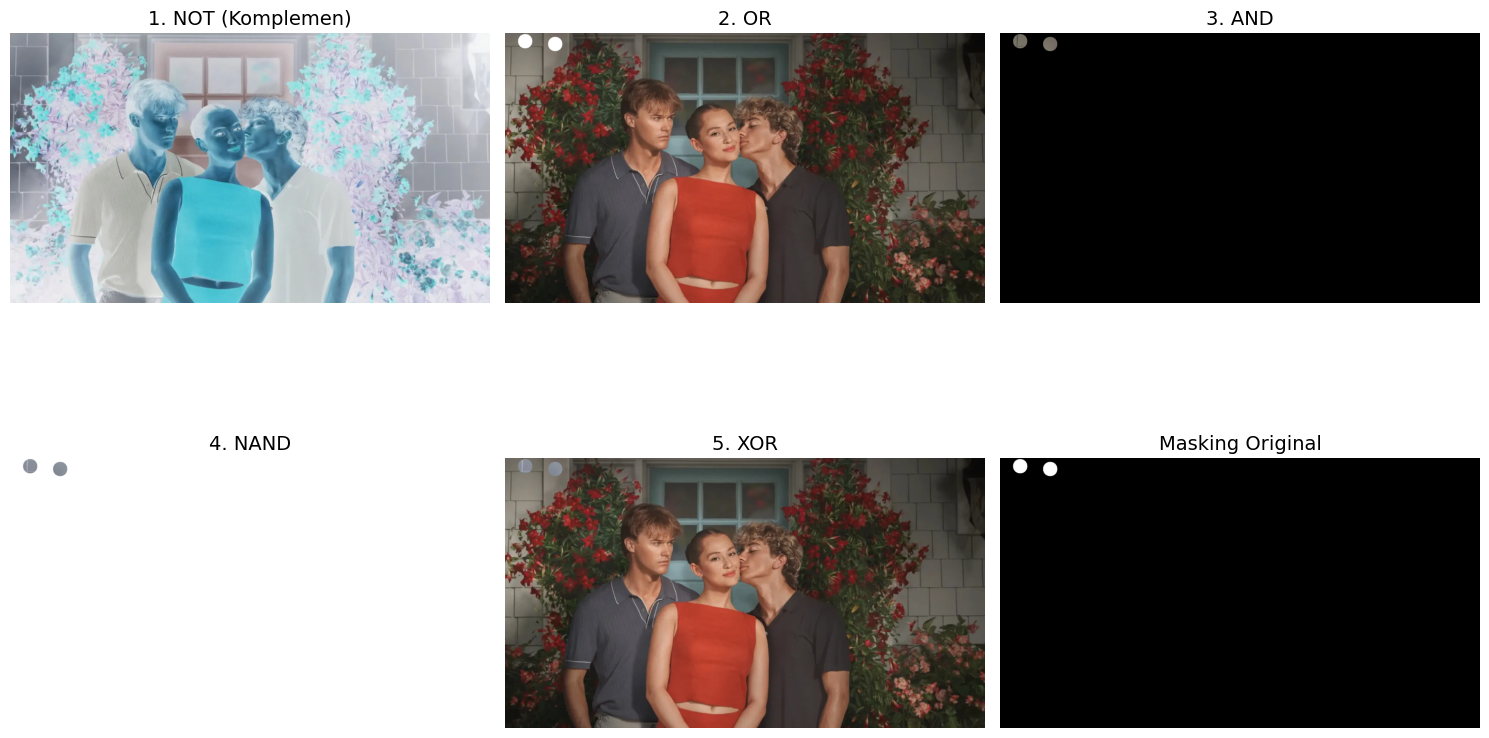

In [41]:
print('--- Eksperimen Image Masking (Bitwise) ---')

path_gambar = '/content/drive/MyDrive/PCdVK/couple.webp'
img_bgr = cv.imread(path_gambar)

if img_bgr is None:
    print("Woi, gambarnya nggak kebaca! Cek lagi path-nya bener apa kagak.")
else:

    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # --- BIKIN MASKING ---
    mask = np.zeros(img_rgb.shape[:2], dtype="uint8")

    cv.circle(mask, (50, 20), 18, 255, -1)
    cv.circle(mask, (125, 27), 18, 255, -1)

    mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2RGB)

    # --- OPERASI BITWISE ---

    # 1. NOT
    hasil_not = cv.bitwise_not(img_rgb)

    # 2. OR
    hasil_or = cv.bitwise_or(img_rgb, mask_3ch)

    # 3. AND
    hasil_and = cv.bitwise_and(img_rgb, mask_3ch)

    # 4. NAND
    hasil_nand = cv.bitwise_not(hasil_and)

    # 5. XOR
    hasil_xor = cv.bitwise_xor(img_rgb, mask_3ch)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    titles = [
        '1. NOT (Komplemen)',
        '2. OR',
        '3. AND',
        '4. NAND',
        '5. XOR',
        'Masking Original'
    ]

    images = [
        hasil_not,
        hasil_or,
        hasil_and,
        hasil_nand,
        hasil_xor,
        mask_3ch
    ]

    for i in range(6):
        axes[i].imshow(images[i])
        axes[i].set_title(titles[i], fontsize=14)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

1. NOT (Komplemen)
Operator NOT membalik nilai setiap piksel pada citra. Nilai piksel yang awalnya terang menjadi gelap, sedangkan piksel yang gelap menjadi terang. Oleh karena itu, hasil citra NOT terlihat seperti negatif dari citra asli.

2. OR (Atau)
Operator OR membandingkan nilai piksel citra dengan mask. Pada bagian yang terkena mask, nilai piksel hasil operasi mengikuti operasi OR sehingga area yang bernilai tinggi pada mask akan membuat bagian tersebut menjadi lebih terang.

3. AND (Dan)
Operator AND hanya mempertahankan nilai piksel pada bagian yang sesuai dengan mask. Karena mask memiliki nilai 255 pada area lingkaran dan 0 pada area lainnya, bagian yang terkena mask tetap terlihat, sedangkan bagian lainnya menjadi hitam. Inilah yang membuat efek masking terlihat jelas.

4. NAND (Not AND)
NAND merupakan kebalikan dari hasil AND. Bagian yang sebelumnya dipertahankan oleh AND akan menjadi kebalikannya, sedangkan bagian di luar area mask menjadi lebih terlihat. Oleh karena itu, hasil NAND tampak seperti inverse dari hasil AND.

5. XOR (Exclusive OR)
Operator XOR menghasilkan perbedaan antara citra dan mask. Pada area yang memiliki perbedaan nilai antara citra dan mask, nilai piksel akan berubah sehingga menghasilkan perubahan/kontras pada area yang terkena mask.

Kesimpulan :
Berdasarkan percobaan, setiap logical operator menghasilkan keluaran citra yang berbeda karena masing-masing melakukan operasi berbeda terhadap nilai piksel citra dan mask. Mask digunakan untuk menentukan area tertentu yang diproses, sehingga bentuk lingkaran pada mask menyebabkan perubahan terutama pada area yang di-highlight. Hasil percobaan menunjukkan bahwa operasi logical dapat digunakan untuk melakukan image masking dan manipulasi bagian tertentu dari citra

--- TUGAS 10: FOTO MALAM HARI ---


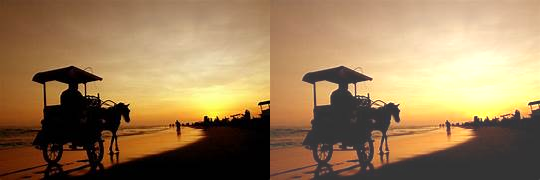

In [43]:
print('--- TUGAS 10: FOTO MALAM HARI ---')

original = cv.imread('/content/drive/MyDrive/PCdVK/sunset.jpg')

if original is None:
    print("Gambar tidak ditemukan!")
else:
    brightness = 50

    brightness_image = cv.convertScaleAbs(
        original,
        alpha=1,
        beta=brightness
    )

    final = cv.hconcat(
        (original, brightness_image)
    )

    cv2_imshow(final)

Metode yang dipilih:
Linear Brightness dengan nilai brightness 50.

Alasan pemilihan:
Metode Linear Brightness dipilih karena foto malam memiliki kondisi pencahayaan yang rendah sehingga beberapa bagian gambar terlihat gelap. Dengan menambahkan nilai brightness, intensitas piksel pada citra meningkat sehingga detail pada bagian yang gelap menjadi lebih terlihat.

Risiko:
Jika nilai brightness terlalu besar, beberapa bagian citra yang sudah terang dapat mengalami overexposure atau menjadi terlalu putih. Selain itu, detail pada area terang dapat hilang karena nilai piksel dibatasi pada rentang 0–255.

--- TUGAS 11: PERBAIKAN KUALITAS CITRA ---


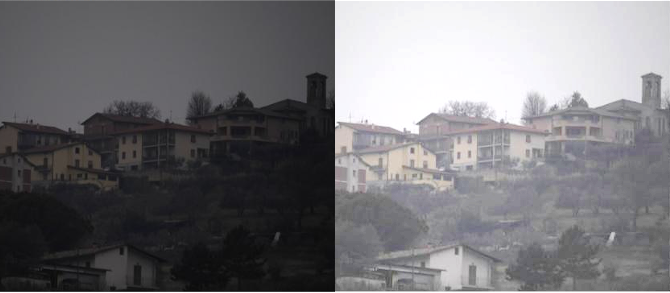

In [44]:
print('--- TUGAS 11: PERBAIKAN KUALITAS CITRA ---')

path_gambar = '/content/drive/MyDrive/PCdVK/kota.png'
original = cv.imread(path_gambar)

if original is None:
    print("Gambar tidak ditemukan!")
else:
    # Gamma Correction
    gamma = 0.5
    normal = original / 255.0
    gamma_image = np.uint8(255 * (normal ** gamma))

    # Contrast dan Brightness
    contrast = 1.5
    brightness = 10

    hasil = cv.convertScaleAbs(
        gamma_image,
        alpha=contrast,
        beta=brightness
    )

    # Before - After
    final = cv.hconcat((original, hasil))
    cv2_imshow(final)

Metode yang dipilih:
Gamma Correction, kemudian dilanjutkan dengan Contrast dan Brightness.

Alasan pemilihan:
Citra kota.png memiliki kondisi pencahayaan yang cukup gelap sehingga beberapa detail bangunan dan lingkungan sulit terlihat. Gamma Correction digunakan untuk meningkatkan kecerahan terutama pada bagian yang gelap. Setelah itu, contrast dan brightness digunakan untuk memperjelas perbedaan antara objek dan latar belakang.

Parameter yang digunakan:
Gamma = 0.5
Contrast = 1.5
Brightness = 10

Hasil:
Pada citra setelah proses, bagian bangunan dan lingkungan yang sebelumnya gelap menjadi lebih terlihat. Kontras juga meningkat sehingga objek pada gambar lebih mudah dibedakan dari latar belakang.